In [16]:
# ============================================================
# Cell 1: Load preprocessed data from S3 output
# These JSON files were produced by our PySpark pipeline on EMR
# ============================================================
from datasets import load_dataset

DATA_DIR = r"C:\Users\Khaled\Desktop\yarn ne5las\S3"

dataset = load_dataset("json", data_files={
    "train": f"{DATA_DIR}/train.json",
    "validation": f"{DATA_DIR}/val.json",
})

print(f"Train samples:      {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"\nSample:\n{dataset['train'][0]['text'][:300]}...")

Train samples:      11989
Validation samples: 2540

Sample:
<|im_start|>system
You are a professional medical assistant. Answer the patient's questions accurately.<|im_end|>
<|im_start|>user
the cancer is called estrogen and/or progesterone receptor positive. this type of breast cancer may grow more quickly. the test results show whether treatment to block e...


In [17]:
# ============================================================
# Cell 2: Load Qwen2.5-1.5B-Instruct (4-bit quantized)
# Using Unsloth for memory-efficient loading
# 4-bit quantization reduces VRAM usage significantly
# ============================================================
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/qwen2.5-1.5b-instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    load_in_4bit=load_in_4bit,
)

if tokenizer.pad_token is None or tokenizer.pad_token == tokenizer.eos_token:
    tokenizer.pad_token = "<|endoftext|>"
    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids("<|endoftext|>")

print("✓ Base model loaded")
print(f"GPU: {torch.cuda.get_device_name(0)}")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 258.24it/s]


unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✓ Base model loaded
GPU: NVIDIA RTX 5000 Ada Generation


In [18]:
# ============================================================
# Cell 3: Test base model BEFORE fine-tuning
# We save these responses to compare with fine-tuned later
# ============================================================
FastLanguageModel.for_inference(model)

test_questions = [
    "What are the symptoms of diabetes?",
    "How is hypertension treated?",
    "What causes migraine headaches?",
]

base_responses = []
for q in test_questions:
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": q}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    outputs = model.generate(
        input_ids=inputs, attention_mask=attention_mask,
        max_new_tokens=512, temperature=0.7, do_sample=True,
        top_p=0.9, repetition_penalty=1.1,
    )
    resp = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    base_responses.append(resp)
    print(f"\nQ: {q}")
    print(f"BASE: {resp[:400]}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEP


Q: What are the symptoms of diabetes?
BASE: Diabetes is a chronic disease that affects how your body uses blood sugar, also called glucose. The main types of diabetes include type 1 and type 2 diabetes.

Type 1 Diabetes:

Symptoms: 

- Frequent urination 
- Increased thirst and hunger  
- Fatigue  
- Blurry vision 
- Tiredness or weakness  
- Slow healing of cuts or bruises  
- Weight loss without trying  
- Unexplained weight gain  
- Dry 


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: How is hypertension treated?
BASE: Hypertension, also known as high blood pressure, is typically managed through lifestyle changes and medications. Here’s how it can be treated:

1. Lifestyle Changes:
   - Maintain a healthy diet: low sodium intake, plenty of fruits and vegetables.
   - Exercise regularly: at least 30 minutes most days of the week.
   - Lose weight if overweight or obese.
   - Quit smoking and limit alcohol consump

Q: What causes migraine headaches?
BASE: Migraine headaches can be caused by a combination of factors including genetics, environmental triggers, and brain chemistry imbalances. The exact cause is not fully understood, but it's believed that certain substances in the blood vessels expand to increase pressure inside the skull, causing pain and other symptoms. Other potential triggers include changes in weather conditions, lack of sleep, f


In [19]:
# ============================================================
# Cell 4: Add LoRA Adapters (PEFT)
# LoRA adds small trainable matrices to attention & FFN layers
# Only ~1-2% of parameters are trained, saving memory & time
# ============================================================
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)

model.print_trainable_parameters()
print("✓ LoRA adapters added")

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
✓ LoRA adapters added


In [20]:
# ============================================================
# Cell 5: Fine-tune with SFTTrainer
# ============================================================
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        warmup_steps=50,
        num_train_epochs=2,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        eval_strategy="steps",
        eval_steps=500,
        save_strategy="no",
        report_to="none",
    ),
)

print("✓ Starting training...")
trainer_stats = trainer.train()
print("✓ Training complete!")

Unsloth: Tokenizing ["text"]: 100%|██████████| 2540/2540 [00:00<00:00, 3328.75 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✓ Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 11,989 | Num Epochs = 2 | Total steps = 2,998
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
500,1.092399,1.032325
1000,1.026951,0.989518
1500,0.946255,0.964293
2000,0.800306,0.958252
2500,0.679922,0.944534
2998,0.851851,0.939368


c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ Training complete!


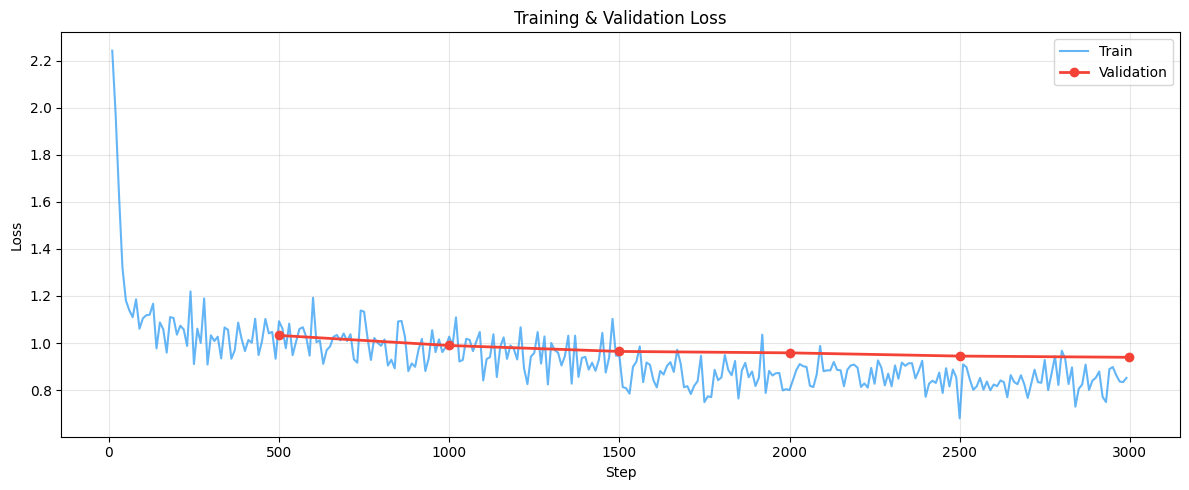

In [21]:
# ============================================================
# Cell 6: Plot training and validation loss curves
# ============================================================
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps_ = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_steps, train_losses, label='Train', alpha=0.7, color='#2196F3')
ax.plot(eval_steps_, eval_losses, label='Validation', color='#F44336',
        linewidth=2, marker='o', markersize=6)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [22]:
# ============================================================
# Cell 7: Compare Base vs Fine-tuned responses
# Required by Section 5 of the deliverable
# ============================================================
FastLanguageModel.for_inference(model)

finetuned_responses = []
for q in test_questions:
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": q}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    outputs = model.generate(
        input_ids=inputs, attention_mask=attention_mask,
        max_new_tokens=512, temperature=0.7, do_sample=True,
        top_p=0.9, repetition_penalty=1.1,
    )
    resp = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    finetuned_responses.append(resp)

for i, q in enumerate(test_questions):
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"{'─'*60}")
    print(f"BASE:\n{base_responses[i][:400]}")
    print(f"{'─'*60}")
    print(f"FINE-TUNED:\n{finetuned_responses[i][:400]}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEP


Q: What are the symptoms of diabetes?
────────────────────────────────────────────────────────────
BASE:
Diabetes is a chronic disease that affects how your body uses blood sugar, also called glucose. The main types of diabetes include type 1 and type 2 diabetes.

Type 1 Diabetes:

Symptoms: 

- Frequent urination 
- Increased thirst and hunger  
- Fatigue  
- Blurry vision 
- Tiredness or weakness  
- Slow healing of cuts or bruises  
- Weight loss without trying  
- Unexplained weight gain  
- Dry 
────────────────────────────────────────────────────────────
FINE-TUNED:
the first symptom is often urinating frequently. people with type 1 or type 2 diabetes may have an unusual thirst as well as increased hunger. they also may lose weight without trying to do so. if untreated, these symptoms can lead to kidney failure, heart disease, stroke, blindness, and nerve damage. the good news is that diabetes complications can be prevented or delayed when diagnosed early.

Q: How is hypertensio

In [26]:
# ============================================================
# Cell 8: Hyperparameter summary table for report
# ============================================================
import pandas as pd

hyperparams = {
    "Parameter": [
        "Base Model", "Parameters", "Quantization",
        "LoRA Rank (r)", "LoRA Alpha", "LoRA Dropout",
        "Target Modules", "Learning Rate", "Batch Size (effective)",
        "Gradient Accumulation", "Epochs", "Warmup Steps",
        "Optimizer", "Weight Decay", "Scheduler",
        "Max Sequence Length", "Train Samples", "Val Samples",
    ],
    "Value": [
        "Qwen 2.5 1.5B Instruct", "1.56B", "4-bit (BnB)",
        "16", "16", "0",
        "q,k,v,o,gate,up,down_proj", "2e-4", "8 (1x8)",
        "8", "2", "50",
        "AdamW 8-bit", "0.01", "Linear",
        "2048", str(len(dataset["train"])), str(len(dataset["validation"])),
    ],
}

hp_df = pd.DataFrame(hyperparams)
print(hp_df.to_string(index=False))

             Parameter                     Value
            Base Model    Qwen 2.5 1.5B Instruct
            Parameters                     1.56B
          Quantization               4-bit (BnB)
         LoRA Rank (r)                        16
            LoRA Alpha                        16
          LoRA Dropout                         0
        Target Modules q,k,v,o,gate,up,down_proj
         Learning Rate                      2e-4
Batch Size (effective)                   8 (1x8)
 Gradient Accumulation                         8
                Epochs                         2
          Warmup Steps                        50
             Optimizer               AdamW 8-bit
          Weight Decay                      0.01
             Scheduler                    Linear
   Max Sequence Length                      2048
         Train Samples                     11989
           Val Samples                      2540


In [24]:
import os
os.environ["PATH"] = r"C:\Users\Khaled\AppData\Local\Programs\Git\cmd;" + os.environ["PATH"]

model.save_pretrained_gguf(
    "medical_qa_gguf",
    tokenizer,
    quantization_method="q4_k_m",
)
print("✓ GGUF exported")

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: C:\Users\Khaled\.cache\huggingface\hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 1000.79it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:05<00:00,  5.51s/it]


Unsloth: Merge process complete. Saved to `c:\Users\Khaled\Desktop\yarn ne5las\medical_qa_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: llama.cpp folder exists but binaries not found - will build
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['medical_qa_gguf_gguf\\Qwen2.5-1.5B-Instruct.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['medical_qa_gguf_gguf\\Qwen2.5-1.5B-Instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: C:\Users\Khaled\.unsloth\llama.cpp\build\bin\Release\llama-cli.exe --model medical_qa_gguf_gguf\Qwen2.5-1.5B-Instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to medical_qa_gguf_gguf\Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f medical_qa_gguf_gguf\Modelfile
✓ GGUF exported


In [25]:
import os
for f in os.listdir(r"C:\Users\Khaled\Desktop\yarn ne5las\medical_qa_gguf"):
    size = os.path.getsize(os.path.join(r"C:\Users\Khaled\Desktop\yarn ne5las\medical_qa_gguf", f))
    print(f"{f:40s} {size/1024/1024:.1f} MB")

.cache                                   0.0 MB
chat_template.jinja                      0.0 MB
config.json                              0.0 MB
generation_config.json                   0.0 MB
model.safetensors                        2944.4 MB
tokenizer.json                           10.9 MB
tokenizer_config.json                    0.0 MB
